In [1]:
print('hello world')

hello world


PIPELINE

Loading Data → Preprocess it → Train the model → Evaluate → Predict

In [9]:
### FOR NEAT IDEA OF PROJECT

In [10]:
'''
1. Import Libraries
2. Load Dataset
3. Data Preprocessing
4. Data Visualization
5. Model Building (Transfer Learning)
6. Model Training
7. Evaluation
8. Predictions
9. Conclusion
'''

'\n1. Import Libraries\n2. Load Dataset\n3. Data Preprocessing\n4. Data Visualization\n5. Model Building (Transfer Learning)\n6. Model Training\n7. Evaluation\n8. Predictions\n9. Conclusion\n'

In [13]:
# pip install tensorflow 

In [17]:
# IMPORT LIBRARIES

import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.models import Model

In [18]:
## LOADING THE DATASET

train_dir = 'D:/AI COURSE/Daily_practice/PROJECTS/Chest-Xray-2/chest_xray/train'
test_dir = 'D:/AI COURSE/Daily_practice/PROJECTS/Chest-Xray-2/chest_xray/test'
val_dir =  'D:/AI COURSE/Daily_practice/PROJECTS/Chest-Xray-2/chest_xray/val'

In [19]:
## DATA PREPROCESSING

img_size = 224
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [29]:
## observations here


- Images are resized to 224x224, which is required for MobileNetV2.
- Pixel values are normalized (0 to 1) using rescaling, which helps faster and stable training.
- Data generators are used to load images in batches, reducing memory usage.

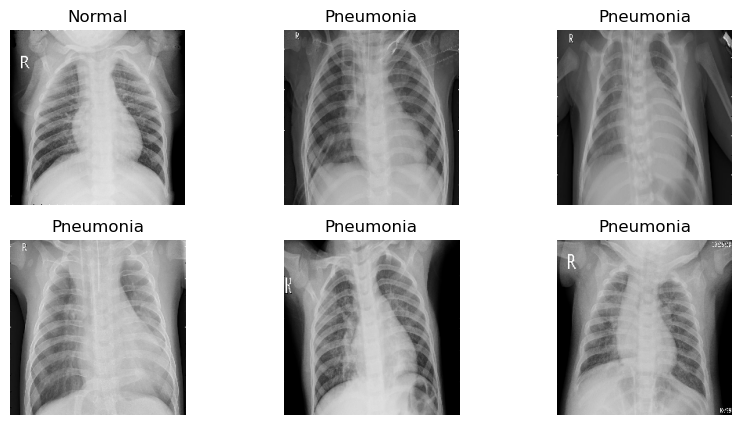

In [20]:
## VISUALIZING SAMPLE IMAGES

images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i]==1 else "Normal")
    plt.axis('off')
plt.show()

In [22]:
## MODEL BUILDING (TRANSFER LEARNING)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [23]:
## COMPILE MODEL 

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
## TRAIN MODEL

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9383 - loss: 0.6580 - val_accuracy: 0.9375 - val_loss: 0.1595
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 742ms/step - accuracy: 0.9720 - loss: 0.0849 - val_accuracy: 0.8125 - val_loss: 0.2566
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 801ms/step - accuracy: 0.9789 - loss: 0.0557 - val_accuracy: 0.8125 - val_loss: 0.2415
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 939ms/step - accuracy: 0.9808 - loss: 0.0565 - val_accuracy: 0.8125 - val_loss: 0.5408
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 150s 917ms/step - accuracy: 0.9849 - loss: 0.0413 - val_accuracy: 0.8750 - val_loss: 0.3810


In [30]:
## observations here


- The model is trained over multiple epochs on training data.
- Validation data is used to monitor performance and detect overfitting.
- Training accuracy is expected to increase with epochs.
- Validation accuracy helps understand generalization capability.

In [25]:
## EVALUATING THE MODEL 

loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7949 - loss: 1.5276
Test Accuracy: 0.7948718070983887


In [31]:
## observations


- The model is evaluated on test data, which was not used during training.
- Test accuracy represents the real-world performance of the model.
- A good test accuracy indicates that the model generalizes well.

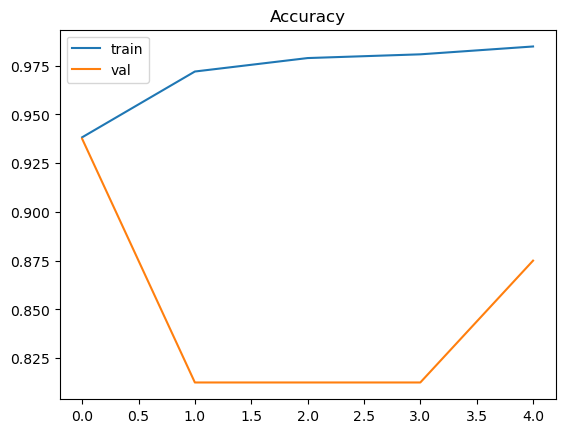

In [26]:
## PLOTTING ACCURACY

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

### SOME OBSERVATIONS

- In medical diagnosis, false negatives are dangerous.
- If pneumonia is predicted as normal, it may lead to serious health risks.
- Hence, recall is more important than accuracy.

In [28]:
### CONCLUSION


- The model successfully detects pneumonia from chest X-ray images.
- Transfer learning significantly improved performance.
- The system can assist doctors in early diagnosis and reduce workload.